In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import cv2

from Flame_fun import process_flame_dataset 

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import r2_score

Calcul en cours pour f = 3...
   Calcul en cours pour le fold 1 / 50...
   Calcul en cours pour le fold 6 / 50...
   Calcul en cours pour le fold 11 / 50...
   Calcul en cours pour le fold 16 / 50...
   Calcul en cours pour le fold 21 / 50...
   Calcul en cours pour le fold 26 / 50...
   Calcul en cours pour le fold 31 / 50...
   Calcul en cours pour le fold 36 / 50...
   Calcul en cours pour le fold 41 / 50...
   Calcul en cours pour le fold 46 / 50...
Calcul en cours pour f = 25...
   Calcul en cours pour le fold 1 / 50...
   Calcul en cours pour le fold 6 / 50...
   Calcul en cours pour le fold 11 / 50...
   Calcul en cours pour le fold 16 / 50...
   Calcul en cours pour le fold 21 / 50...
   Calcul en cours pour le fold 26 / 50...
   Calcul en cours pour le fold 31 / 50...
   Calcul en cours pour le fold 36 / 50...
   Calcul en cours pour le fold 41 / 50...
   Calcul en cours pour le fold 46 / 50...
Calcul en cours pour f = 30...
   Calcul en cours pour le fold 1 / 50...
   Calcul 

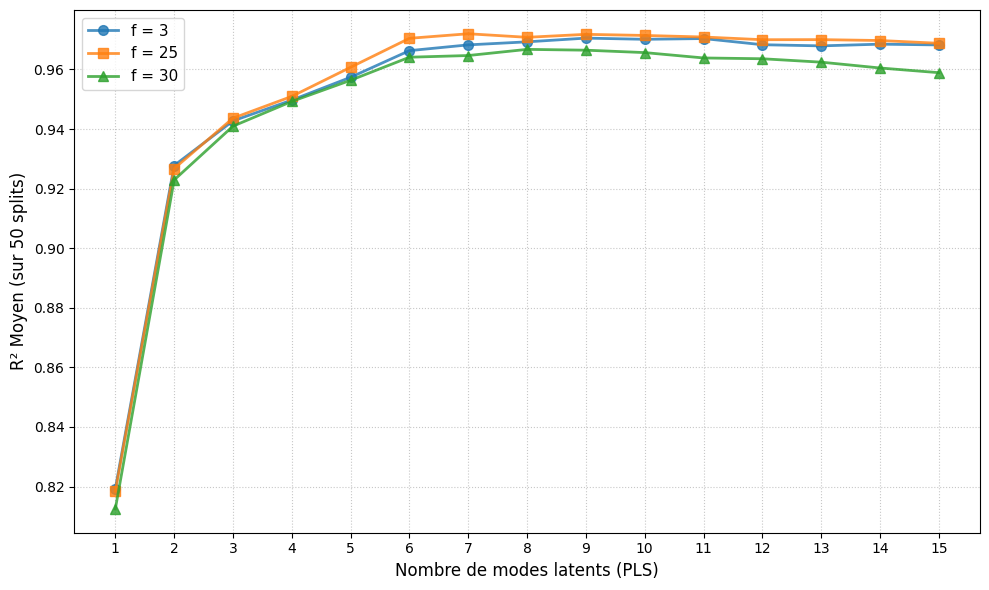

In [ ]:
# Chargement des données
csv_path = "Data4ML.csv"
df = pd.read_csv(csv_path, sep=";") 
base_image_folder = r".\data"   

# On teste ici plusieurs facteurs de sous-échantillonnage spatial.
# L'idée est d'évaluer l'effet de la résolution image sur les performances du modèle PLS pour la prédiction de la longueur de flamme.
# On évalue également le nombre de modes optimal pour le futur entrainement d'un modèle GPR sur chaque coeff de mode

f1 = 3
imgs_f1, _, _ = process_flame_dataset(csv_path, base_image_folder, f1) 

f2 = 25
imgs_f2, _, _ = process_flame_dataset(csv_path, base_image_folder, f2) 

f3 = 30 
imgs_f3, _, FL_list = process_flame_dataset(csv_path, base_image_folder, f3) 
FL_array = np.array(FL_list).reshape(-1, 1)

# Paramètres de l'étude
n_max_modes = 15 
test_ratio = 0.1
n_splits = 50

# Validation croisée répétée par tirages aléatoires train/test
cv = ShuffleSplit(n_splits=n_splits, test_size=test_ratio, random_state=42)

# Dictionnaire des datasets à comparer
datasets = {
    f"f = {f1}": imgs_f1,
    f"f = {f2}": imgs_f2,
    f"f = {f3}": imgs_f3
}

# Stockage du R² moyen pour chaque dataset et chaque nombre de modes
r2_results = {key: np.zeros(n_max_modes) for key in datasets.keys()}
modes_range = range(1, n_max_modes + 1)

# Boucle principale : évaluation PLS pour chaque résolution
for name, imgs in datasets.items():
    print(f"Calcul en cours pour {name}...")
    
    fold_scores = np.zeros((n_splits, n_max_modes))
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(imgs)):
        if fold % 5 == 0 : print(f"   Calcul en cours pour le fold {fold+1} / {n_splits}...")

        # Séparation train / test
        imgs_tr, imgs_te = imgs[train_idx], imgs[test_idx]
        y_tr, y_te = FL_array[train_idx], FL_array[test_idx]
        
        # Ajustement du modèle PLS avec le nombre maximal de modes
        # Puis reconstrucrion des prédictions pour 1 à n_max_modes sans refaire un fit complet à chaque fois.
        pls = PLSRegression(n_components=n_max_modes)
        pls.fit(imgs_tr, y_tr)
        
        x_std_safe = pls._x_std.copy()
        x_std_safe[x_std_safe == 0] = 1.0 
        X_te_center = (imgs_te - pls._x_mean) / x_std_safe
        
        # Évaluation progressive selon le nombre de modes latents conservés
        for i, m in enumerate(modes_range):
            # On tronque les matrices PLS aux m premiers modes
            W_star_m = pls.x_rotations_[:, :m]
            q_m = pls.y_loadings_[:, :m]
            
            # Prédiction dans l'espace réduit puis retour à l'échelle initiale            
            y_pred_k = X_te_center @ W_star_m @ q_m.T
            y_pred_finale = y_pred_k * pls._y_std + pls._y_mean  
            fold_scores[fold, i] = r2_score(y_te, y_pred_finale)
            
    # Moyenne des performances sur tous les splits
    r2_results[name] = np.mean(fold_scores, axis=0)

print("Calculs terminés, Génération du graphique...")

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for (name, r2_scores), color, marker in zip(r2_results.items(), colors, markers):
    plt.plot(modes_range, r2_scores, label=name, color=color, marker=marker, 
             linewidth=2, markersize=7, alpha=0.8)

plt.xlabel('Nombre de modes latents (PLS)', fontsize=12)
plt.ylabel(f'R² Moyen (sur {n_splits} splits)', fontsize=12)
plt.xticks(modes_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Calcul en cours pour f = 5...
   Calcul en cours pour le fold 1 / 50...
   Calcul en cours pour le fold 6 / 50...
   Calcul en cours pour le fold 11 / 50...
   Calcul en cours pour le fold 16 / 50...
   Calcul en cours pour le fold 21 / 50...
   Calcul en cours pour le fold 26 / 50...
   Calcul en cours pour le fold 31 / 50...
   Calcul en cours pour le fold 36 / 50...
   Calcul en cours pour le fold 41 / 50...
   Calcul en cours pour le fold 46 / 50...
Calcul en cours pour f = 10...
   Calcul en cours pour le fold 1 / 50...
   Calcul en cours pour le fold 6 / 50...
   Calcul en cours pour le fold 11 / 50...
   Calcul en cours pour le fold 16 / 50...
   Calcul en cours pour le fold 21 / 50...
   Calcul en cours pour le fold 26 / 50...
   Calcul en cours pour le fold 31 / 50...
   Calcul en cours pour le fold 36 / 50...
   Calcul en cours pour le fold 41 / 50...
   Calcul en cours pour le fold 46 / 50...
Calcul en cours pour f = 25...
   Calcul en cours pour le fold 1 / 50...
   Calcul 

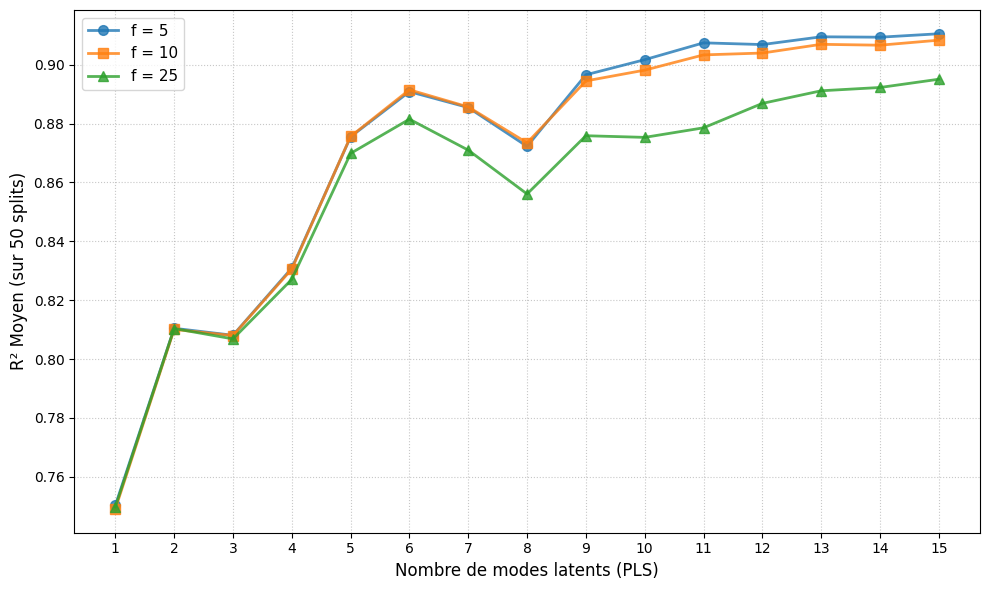

In [4]:
## Même procédure que précément, mais cette fois-ci on utilise FL / d1 et non plus FL
# On montre ici que si la longueur de flamme normalisée donne de meilleures résultats pour une approche directe par machine learning
# dans ce cas on doit s'interesser à FL. 

csv_path = "Data4ML.csv"
df = pd.read_csv(csv_path, sep=";") 
base_image_folder = r".\data"

f1 = 5
imgs_f1, _, _ = process_flame_dataset(csv_path, base_image_folder, f1) 

f2 = 10
imgs_f2, _, _ = process_flame_dataset(csv_path, base_image_folder, f2) 

f3 = 25
imgs_f3, _, FL_list = process_flame_dataset(csv_path, base_image_folder, f3) 
FL_array_norm = (np.array(FL_list) / df['d1'].values).reshape(-1, 1) # On utilise FL_array_norm et non pas FL_array

n_max_modes = 15 
test_ratio = 0.1
n_splits = 50
cv = ShuffleSplit(n_splits=n_splits, test_size=test_ratio, random_state=42)

datasets = {
    f"f = {f1}": imgs_f1,
    f"f = {f2}": imgs_f2,
    f"f = {f3}": imgs_f3
}

r2_results = {key: np.zeros(n_max_modes) for key in datasets.keys()}
modes_range = range(1, n_max_modes + 1)

for name, imgs in datasets.items():
    print(f"Calcul en cours pour {name}...")
    
    fold_scores = np.zeros((n_splits, n_max_modes))
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(imgs)):
        if fold % 5 == 0 : print(f"   Calcul en cours pour le fold {fold+1} / {n_splits}...")

        imgs_tr, imgs_te = imgs[train_idx], imgs[test_idx]
        y_tr, y_te = FL_array_norm[train_idx], FL_array_norm[test_idx]
        
        pls = PLSRegression(n_components=n_max_modes)
        pls.fit(imgs_tr, y_tr)
        
        x_std_safe = pls._x_std.copy()
        x_std_safe[x_std_safe == 0] = 1.0 
        
        X_te_center = (imgs_te - pls._x_mean) / x_std_safe
        
        for i, m in enumerate(modes_range):
            
            W_star_m = pls.x_rotations_[:, :m]
            q_m = pls.y_loadings_[:, :m]
            
            y_pred_k = X_te_center @ W_star_m @ q_m.T
            y_pred_finale = y_pred_k * pls._y_std + pls._y_mean  
            fold_scores[fold, i] = r2_score(y_te, y_pred_finale)
            
    r2_results[name] = np.mean(fold_scores, axis=0)

print("Calculs terminés ! Génération du graphique...")

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for (name, r2_scores), color, marker in zip(r2_results.items(), colors, markers):
    plt.plot(modes_range, r2_scores, label=name, color=color, marker=marker, 
             linewidth=2, markersize=7, alpha=0.8)

plt.xlabel('Nombre de modes latents (PLS)', fontsize=12)
plt.ylabel(f'R² Moyen (sur {n_splits} splits)', fontsize=12)
plt.xticks(modes_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

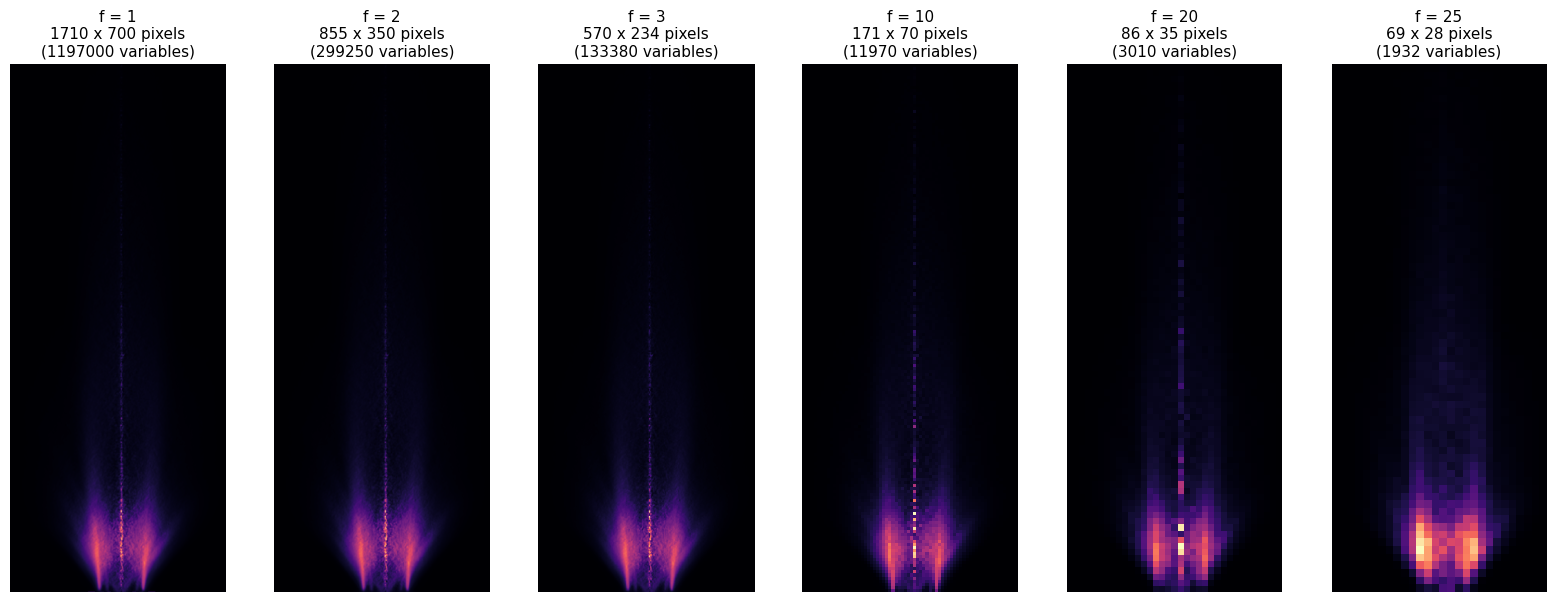

In [6]:
# Illustration de l'effet du sous-échantillonnage spatial :
# on visualise comment la résolution (et donc la dimension du problème) diminue avec f

_, img_haute_res, _ = process_flame_dataset(csv_path, base_image_folder, 1)

facteurs = [1, 2, 3, 10, 20, 25]

fig, axes = plt.subplots(1, len(facteurs), figsize=(16, 6))

for ax, f in zip(axes, facteurs):
    img_reduite = img_haute_res[::f, ::f]
    ax.imshow(img_reduite, cmap='magma')
    hauteur, largeur = img_reduite.shape
    ax.set_title(f"f = {f}\n{hauteur} x {largeur} pixels\n({hauteur * largeur} variables)", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

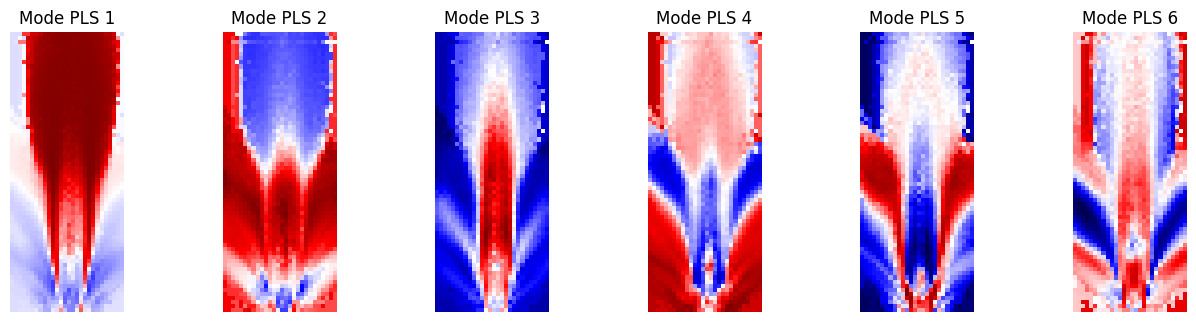

In [7]:
## Observation des modes PLS :

# Objectif :
# visualiser les structures spatiales apprises par le modèle PLS,
# c'est-à-dire les directions de l'image les plus corrélées à la longueur de flamme.

imgs, mean_flame_image, FL_list = process_flame_dataset(csv_path,base_image_folder,25) 
FL_array = np.array(FL_list).reshape(-1,1)

# Nombre de composantes latentes PLS à analyser
n_modes = 6
pls_global = PLSRegression(n_components=n_modes)
pls_global.fit(imgs, FL_array)

H, W = mean_flame_image.shape

n_plots = 6

plt.figure(figsize=(16, 8))

for k in range(n_plots) : 
    plt.subplot(2, 6, k+1)
    
    # x_loadings_ = directions dans l'espace image qui expliquent la covariance avec la cible
    # → ici, chaque "mode PLS" correspond à une structure spatiale influente pour FL
    mode_image = pls_global.x_loadings_[:, k].reshape(H, W)
    max_val = np.max(np.abs(mode_image))
    
    # Échelle symétrique pour visualiser les contributions positives / négatives
    # (zones qui augmentent ou diminuent la longueur de flamme)
    plt.imshow(mode_image, cmap='seismic', vmin=-max_val, vmax=max_val)
    plt.title(f"Mode PLS {k+1}")
    plt.axis('off')
    
plt.show()

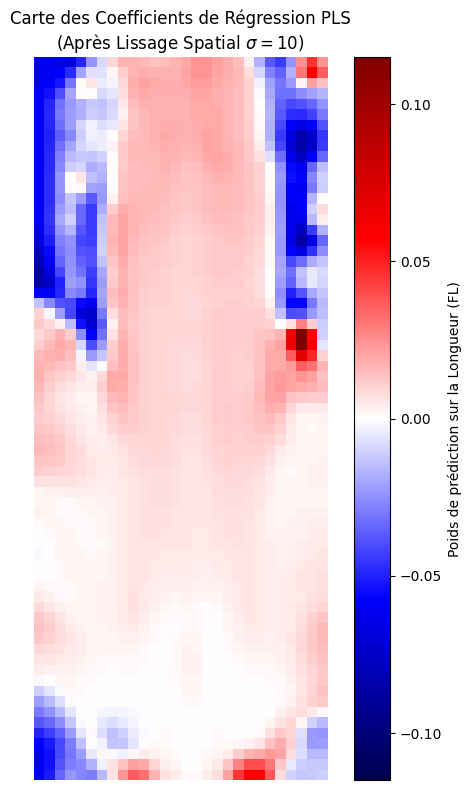

In [10]:
from scipy.ndimage import gaussian_filter 

# Visualisation de la carte de prédiction PLS
# Objectif :
# identifier quelles zones de l'image contribuent le plus à la prédiction
# de la longueur de flamme (interprétation du modèle).

# Carte brute des coefficients :
# chaque pixel est associé à un poids → influence sur la prédiction finale
carte_predictive_brute = pls_global.coef_.reshape(H, W)

# --- LISSAGE SPATIAL ---
# Le modèle PLS peut produire une carte bruitée (pixel à pixel).
# On applique un flou gaussien pour révéler les structures spatiales dominantes.
# sigma contrôle le niveau de lissage (plus grand = plus lisse)
carte_lissee = gaussian_filter(carte_predictive_brute, sigma=1)

plt.figure(figsize=(6, 8))

# Échelle symétrique pour comparer les contributions positives / négatives
max_val = np.max(np.abs(carte_lissee))

plt.imshow(carte_lissee, cmap='seismic', vmin=-max_val, vmax=max_val)
plt.colorbar(label="Poids de prédiction sur la Longueur (FL)")
plt.title("Carte des Coefficients de Régression PLS\n(Après Lissage Spatial $\sigma=10$)")
plt.axis('off')
plt.tight_layout()
plt.show()